# Proyecto 2: Análisis Exploratorio
## CommonLit - Evaluate Student Summaries


Reto seleccionado: **#12 - CommonLit: Evaluar resúmenes de estudiantes** (Procesamiento del Lenguaje Natural)

Competencia de Kaggle: [CommonLit - Evaluate Student Summaries](https://www.kaggle.com/competitions/commonlit-evaluate-student-summaries/data)

## 1. Situación problemática

Redactar un resumen es una de las habilidades más importantes que un estudiante desarrolla a lo largo de su formación académica. Resumir un texto obliga al estudiante a identificar la idea principal, distinguirla de los detalles secundarios y expresarla nuevamente con sus propias palabras de forma clara y coherente. Por esta razón, la habilidad de resumen está directamente relacionada con la comprensión lectora, y es especialmente relevante para estudiantes que están aprendiendo un segundo idioma o que presentan alguna dificultad de aprendizaje, ya que refuerza tanto la lectura crítica como la escritura.

A pesar de su importancia, los estudiantes de los grados 3 a 12 (educación primaria y secundaria en el sistema estadounidense) rara vez tienen suficientes oportunidades para practicar esta habilidad de forma constante. La razón principal es que evaluar un resumen es una tarea que consume mucho tiempo para los docentes: a diferencia de una pregunta de opción múltiple, calificar un resumen requiere que el profesor lea tanto el texto original como el resumen del estudiante, y luego juzgue de forma subjetiva qué tan bien se representaron las ideas principales y los detalles del texto fuente, además de la calidad del lenguaje empleado (claridad, precisión y fluidez). Cuando un docente tiene decenas o cientos de estudiantes, revisar resumen por resumen se vuelve una carga de trabajo poco sostenible, lo que reduce la frecuencia con la que se asignan este tipo de ejercicios y retrasa la retroalimentación que reciben los estudiantes.

En los últimos años han surgido técnicas de calificación automática de escritura (Automated Writing Evaluation), pero estas se han enfocado principalmente en géneros como el ensayo argumentativo o narrativo, donde el modelo solo necesita evaluar el texto del estudiante de forma aislada. La evaluación de resúmenes agrega una capa adicional de complejidad: el modelo no solo debe analizar la calidad interna del texto escrito por el estudiante, sino también compararlo contra un texto fuente más largo para determinar qué tan fielmente se representó su contenido. Las pocas técnicas existentes para evaluar resúmenes se han entrenado y probado sobre resúmenes generados automáticamente (por otros modelos de lenguaje), y no sobre escritura real de estudiantes, que presenta errores gramaticales, ideas incompletas, paráfrasis pobres y una gran variabilidad en extensión y estilo propia de la edad y el nivel de cada estudiante.

Esta situación plantea una oportunidad concreta: si se dispusiera de un modelo capaz de evaluar automáticamente, de forma confiable, tanto el contenido (*content*) como la redacción (*wording*) de un resumen escrito por un estudiante real, los docentes podrían asignar más ejercicios de resumen sin incrementar su carga de trabajo, y las plataformas educativas podrían ofrecer retroalimentación inmediata a los estudiantes mientras practican, acelerando su proceso de aprendizaje.

## 2. Problema científico

¿En qué medida es posible predecir de forma automática, mediante técnicas de Procesamiento del Lenguaje Natural (NLP) y aprendizaje automático supervisado, las puntuaciones de **contenido** (*content*) y **redacción** (*wording*) que un evaluador humano asignaría a un resumen escrito por un estudiante de los grados 3 a 12, utilizando únicamente el texto del resumen y el texto fuente (*prompt*) a partir del cual fue escrito?

De este problema general se desprenden preguntas más específicas que guiarán el análisis:

- ¿Qué características textuales del resumen (longitud, superposición léxica con el texto fuente, diversidad de vocabulario, estructura gramatical) se relacionan más fuertemente con la puntuación de *content* y cuáles con la de *wording*?
- ¿Las puntuaciones de *content* y *wording* están correlacionadas entre sí, o miden aspectos suficientemente distintos del resumen como para requerir un tratamiento independiente?
- ¿Un modelo entrenado con los resúmenes de un conjunto reducido de textos fuente (prompts) es capaz de generalizar su evaluación a resúmenes de textos fuente completamente distintos, dado que el conjunto de entrenamiento y el de prueba no comparten *prompts*?
- ¿Qué tanta variabilidad existe en la forma de escribir de estudiantes reales (longitud, errores, estilo) y cómo afecta esa variabilidad la dificultad de construir un modelo de evaluación confiable, en comparación con evaluar resúmenes generados por otros modelos de lenguaje?

Responder estas preguntas mediante un análisis exploratorio riguroso es el primer paso necesario antes de poder plantear y validar un modelo predictivo de evaluación automática de resúmenes.

## 3. Objetivos

### Objetivo general

Realizar un análisis exploratorio de los datos de la competencia *CommonLit: Evaluate Student Summaries*, con el fin de caracterizar los resúmenes escritos por estudiantes y los textos fuente de los que provienen, e identificar los patrones y relaciones entre las variables textuales y las puntuaciones de *content* y *wording* que sienten las bases para el desarrollo de un futuro modelo predictivo de evaluación automática.

### Objetivos específicos

1. Describir la estructura de los conjuntos de datos `summaries_train.csv` y `prompts_train.csv` (número de variables, número de observaciones y tipo de cada variable), y aplicar las tareas de limpieza y preprocesamiento necesarias (verificación de duplicados, valores faltantes y consistencia de los identificadores entre ambos conjuntos).
2. Calcular estadísticas descriptivas de las variables numéricas (`content`, `wording` y la longitud de los resúmenes en palabras/caracteres) y tablas de frecuencia para la variable categórica `prompt_id`, con el fin de cuantificar la distribución de las puntuaciones y de las observaciones por texto fuente.
3. Analizar, mediante gráficos exploratorios (histogramas, diagramas de caja y dispersión) y el cálculo de correlaciones, la relación entre la longitud/características del resumen y las puntuaciones de `content` y `wording`, así como la relación entre ambas puntuaciones entre sí y entre los distintos `prompt_id`, con el objetivo de identificar los factores que más explican la variabilidad en la calidad de los resúmenes.

## 4. Descripción de los datos

El conjunto de datos de la competencia está compuesto por cuatro archivos principales: `summaries_train.csv`, `prompts_train.csv`, `summaries_test.csv` y `prompts_test.csv`. Dado que los archivos de prueba (`test`) solo contienen 2 *prompts* y 4 resúmenes de ejemplo (son *placeholders* que Kaggle reemplaza por el conjunto de prueba real y oculto al momento de evaluar), el análisis exploratorio de este documento se centra en los archivos de entrenamiento, que son los que contienen datos reales y completos.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

summaries_train = pd.read_csv("../data/summaries_train.csv")
prompts_train = pd.read_csv("../data/prompts_train.csv")

print("summaries_train:", summaries_train.shape)
print("prompts_train:", prompts_train.shape)

summaries_train: (7165, 5)
prompts_train: (4, 4)


`summaries_train.csv` tiene **7,165 observaciones y 5 variables**:

| Variable | Tipo | Descripción |
|---|---|---|
| `student_id` | Cualitativa nominal (identificador) | Identificador único del estudiante que escribió el resumen |
| `prompt_id` | Cualitativa nominal (categórica) | Identificador del texto fuente que el estudiante resumió; enlaza con `prompts_train.csv` |
| `text` | Cualitativa (texto libre) | Texto completo del resumen escrito por el estudiante |
| `content` | Cuantitativa continua (variable objetivo) | Puntuación de contenido del resumen (qué tan bien representa la idea principal y los detalles del texto fuente) |
| `wording` | Cuantitativa continua (variable objetivo) | Puntuación de redacción del resumen (claridad, precisión y fluidez del lenguaje) |

`prompts_train.csv` tiene **4 observaciones y 4 variables**:

| Variable | Tipo | Descripción |
|---|---|---|
| `prompt_id` | Cualitativa nominal (identificador) | Identificador único del texto fuente |
| `prompt_question` | Cualitativa (texto libre) | Pregunta específica que se le pidió responder al estudiante |
| `prompt_title` | Cualitativa nominal | Título corto del texto fuente |
| `prompt_text` | Cualitativa (texto libre) | Texto completo del material que los estudiantes debían resumir |

`content` y `wording` no son calificaciones en una escala fija (por ejemplo, de 1 a 5), sino puntuaciones continuas ya estandarizadas (pueden tomar valores negativos), obtenidas mediante un proceso de calificación comparativa entre resúmenes por parte de evaluadores expertos.

In [4]:
print("Tipos de dato - summaries_train:")
print(summaries_train.dtypes)
print("\nTipos de dato - prompts_train:")
print(prompts_train.dtypes)

Tipos de dato - summaries_train:
student_id     object
prompt_id      object
text           object
content       float64
wording       float64
dtype: object

Tipos de dato - prompts_train:
prompt_id          object
prompt_question    object
prompt_title       object
prompt_text        object
dtype: object


### 4.1 Limpieza y preprocesamiento

Se verifican valores faltantes, filas duplicadas y la consistencia de los identificadores `prompt_id` entre ambos archivos, y se generan variables derivadas de longitud de texto que se usarán en el análisis exploratorio.

In [5]:
# Valores faltantes
print("Valores faltantes - summaries_train:")
print(summaries_train.isna().sum())
print("\nValores faltantes - prompts_train:")
print(prompts_train.isna().sum())

# Duplicados
print("\nFilas duplicadas en summaries_train:", summaries_train.duplicated().sum())
print("student_id duplicados:", summaries_train["student_id"].duplicated().sum())

# Consistencia de prompt_id entre ambos datasets
prompts_en_summaries = set(summaries_train["prompt_id"].unique())
prompts_en_prompts = set(prompts_train["prompt_id"].unique())
print("\nprompt_id únicos en summaries_train:", prompts_en_summaries)
print("prompt_id únicos en prompts_train:", prompts_en_prompts)
print("¿Coinciden exactamente?", prompts_en_summaries == prompts_en_prompts)

Valores faltantes - summaries_train:
student_id    0
prompt_id     0
text          0
content       0
wording       0
dtype: int64

Valores faltantes - prompts_train:
prompt_id          0
prompt_question    0
prompt_title       0
prompt_text        0
dtype: int64

Filas duplicadas en summaries_train: 0
student_id duplicados: 0

prompt_id únicos en summaries_train: {'39c16e', '814d6b', '3b9047', 'ebad26'}
prompt_id únicos en prompts_train: {'ebad26', '814d6b', '39c16e', '3b9047'}
¿Coinciden exactamente? True


In [6]:
# Variables derivadas de longitud de texto (necesarias para el análisis exploratorio)
summaries_train["text_len_words"] = summaries_train["text"].str.split().str.len()
summaries_train["text_len_chars"] = summaries_train["text"].str.len()

summaries_train[["text_len_words", "text_len_chars"]].describe()

,text_len_words,text_len_chars
count,7165.000000,7165.000000
mean,74.811724,418.776971
std,53.503992,307.833685
min,22.000000,114.000000
25%,39.000000,216.000000
50%,58.000000,320.000000
75%,92.000000,513.000000
max,647.000000,3940.000000


**Hallazgos de la limpieza de datos:**

- Ninguna de las 5 variables de `summaries_train` ni de las 4 variables de `prompts_train` presenta valores faltantes.
- No existen filas duplicadas ni `student_id` repetidos: cada una de las 7,165 observaciones corresponde a un resumen distinto de un estudiante distinto.
- Los 4 valores únicos de `prompt_id` en `summaries_train` coinciden exactamente con los 4 `prompt_id` de `prompts_train`, por lo que ambas tablas pueden combinarse (`merge`) sin pérdida ni generación de valores nulos.
- Los resúmenes tienen una longitud muy variable: entre 22 y 647 palabras (promedio ≈ 75 palabras, mediana ≈ 58), lo que confirma la heterogeneidad propia de la escritura real de estudiantes y sugiere que la longitud del resumen es una variable a considerar en el análisis exploratorio.

Dado que el conjunto de datos ya llega limpio (sin nulos ni duplicados), el preprocesamiento se limitó a verificar su integridad y a construir las variables derivadas de longitud de texto que se utilizarán en la siguiente sección.

## 5. Análisis Exploratorio de Datos (EDA)

### 5.1 Resumen de variables numéricas

In [7]:
numeric_cols = ["content", "wording", "text_len_words", "text_len_chars"]
summaries_train[numeric_cols].describe()

,content,wording,text_len_words,text_len_chars
count,7165.000000,7165.000000,7165.000000,7165.000000
mean,-0.014853,-0.063072,74.811724,418.776971
std,1.043569,1.036048,53.503992,307.833685
min,-1.729859,-1.962614,22.000000,114.000000
25%,-0.799545,-0.872720,39.000000,216.000000
50%,-0.093814,-0.081769,58.000000,320.000000
75%,0.499660,0.503833,92.000000,513.000000
max,3.900326,4.310693,647.000000,3940.000000


**Hallazgos:**

- `content` tiene media ≈ -0.01 y `wording` media ≈ -0.06, ambas con desviación estándar ≈ 1.0: son puntuaciones ya estandarizadas, centradas alrededor de 0, y no en una escala natural tipo 0-100.
- Ambas variables tienen un rango que va aproximadamente de -1.7/-2.0 hasta un máximo de 3.9/4.3, es decir, la cola derecha (resúmenes excepcionalmente buenos) es más larga que la izquierda, lo que sugiere una distribución con sesgo positivo.
- La longitud de los resúmenes es muy variable: en palabras va de 22 a 647 (media ≈ 75, mediana ≈ 58), y el hecho de que la media sea mayor que la mediana confirma un sesgo hacia la derecha (unos pocos estudiantes escriben resúmenes muy extensos).

### 5.2 Tabla de frecuencia y proporciones de la variable categórica `prompt_id`

In [8]:
freq_table = summaries_train["prompt_id"].value_counts().rename("frecuencia").to_frame()
freq_table["proporcion"] = (freq_table["frecuencia"] / len(summaries_train)).round(3)
freq_table = freq_table.merge(
    prompts_train[["prompt_id", "prompt_title"]], left_index=True, right_on="prompt_id"
).set_index("prompt_id")

freq_table

,frecuencia,proporcion,prompt_title
prompt_id,,,
39c16e,2057,0.287,On Tragedy
3b9047,2009,0.280,Egyptian Social Structure
ebad26,1996,0.279,Excerpt from The Jungle
814d6b,1103,0.154,The Third Wave


**Hallazgos:** las observaciones no están distribuidas de forma equitativa entre los 4 *prompts*. "On Tragedy" y "Egyptian Social Structure" concentran cerca del 57% de los resúmenes (29% y 28% respectivamente), mientras que "The Third Wave" solo representa el 15% del total. Este desbalance es importante porque, al no compartir *prompts* entre entrenamiento y prueba, un futuro modelo debe aprender patrones generalizables al tema del texto y no memorizar particularidades de los 4 textos fuente vistos en entrenamiento.

### 5.3 Gráfico de barras: número de resúmenes por prompt

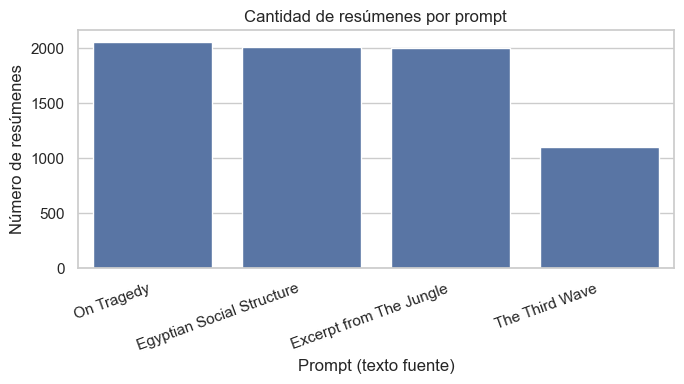

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    x=freq_table["prompt_title"], y=freq_table["frecuencia"], ax=ax, color="#4C72B0"
)
ax.set_xlabel("Prompt (texto fuente)")
ax.set_ylabel("Número de resúmenes")
ax.set_title("Cantidad de resúmenes por prompt")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### 5.4 Histogramas de las variables numéricas

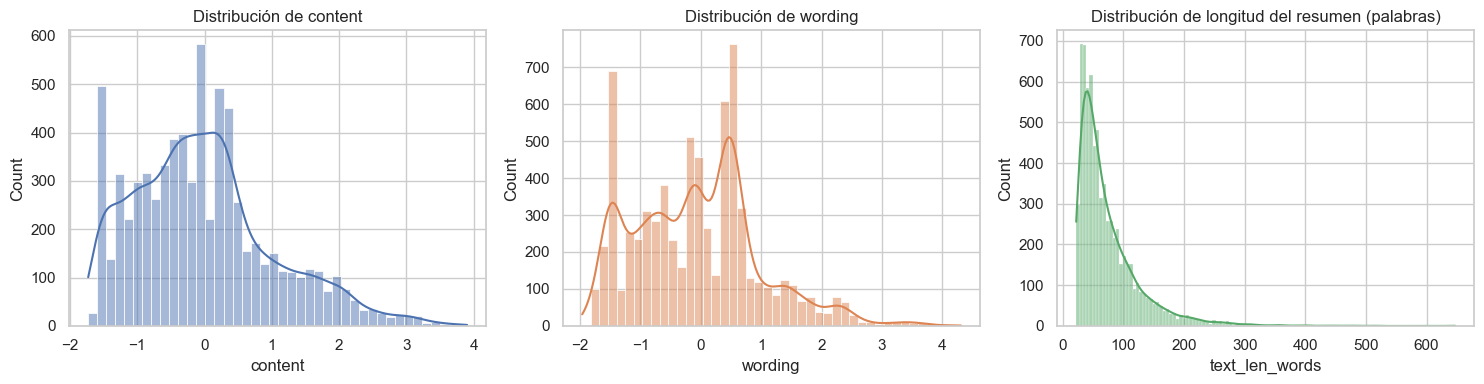

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(summaries_train["content"], kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribución de content")

sns.histplot(summaries_train["wording"], kde=True, ax=axes[1], color="#DD8452")
axes[1].set_title("Distribución de wording")

sns.histplot(summaries_train["text_len_words"], kde=True, ax=axes[2], color="#55A868")
axes[2].set_title("Distribución de longitud del resumen (palabras)")

plt.tight_layout()
plt.show()

**Hallazgos:** `content` y `wording` muestran una forma aproximadamente unimodal y campaniforme, cercana a una normal, aunque con una cola derecha ligeramente más larga (algunos resúmenes destacan muy por encima del promedio). La longitud del resumen en palabras, en cambio, presenta un sesgo positivo mucho más marcado: la mayoría de estudiantes escribe resúmenes cortos (concentrados entre 30 y 100 palabras), con una cola larga de resúmenes extensos que llegan hasta las 647 palabras.

### 5.5 Cruce de variables: puntuaciones por prompt (diagramas de caja) y outliers

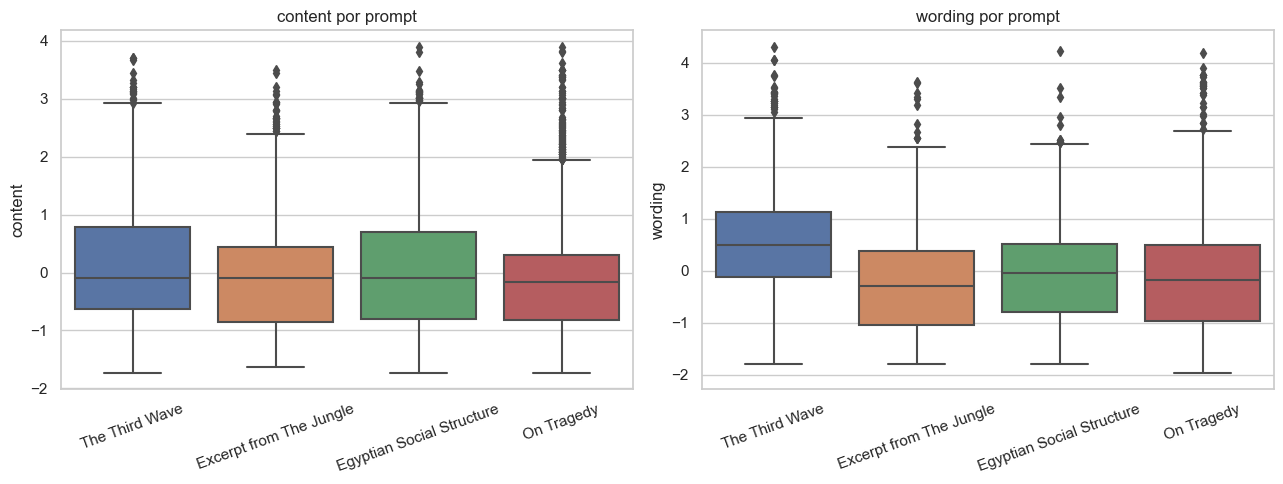

content             wording          
                               mean       std      mean       std
prompt_title                                                     
Egyptian Social Structure  0.049579  1.106129 -0.068542  0.952708
Excerpt from The Jungle   -0.087906  0.990271 -0.299023  0.930270
On Tragedy                -0.095457  0.969773 -0.140749  1.055695
The Third Wave             0.150306  1.124158  0.518733  1.107806

In [11]:
summaries_train = summaries_train.merge(
    prompts_train[["prompt_id", "prompt_title"]], on="prompt_id", how="left"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=summaries_train, x="prompt_title", y="content", ax=axes[0])
axes[0].set_title("content por prompt")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=summaries_train, x="prompt_title", y="wording", ax=axes[1])
axes[1].set_title("wording por prompt")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

summaries_train.groupby("prompt_title")[["content", "wording"]].agg(["mean", "std"])

In [12]:
def contar_outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((serie < limite_inf) | (serie > limite_sup)).sum()
    return n_outliers, limite_inf, limite_sup

for col in ["content", "wording"]:
    n_out, low, high = contar_outliers_iqr(summaries_train[col])
    pct = 100 * n_out / len(summaries_train)
    print(f"{col}: {n_out} outliers ({pct:.1f}%) fuera de [{low:.2f}, {high:.2f}]")

content: 170 outliers (2.4%) fuera de [-2.75, 2.45]
wording: 87 outliers (1.2%) fuera de [-2.94, 2.57]


**Hallazgos:** las medias de `content` y `wording` varían entre prompts (por ejemplo, "The Third Wave" tiene la media de `content` más alta y "On Tragedy" la más baja), lo que sugiere que la dificultad o la naturaleza de cada texto fuente influye en qué tan bien logran resumirlo los estudiantes, y es una razón adicional por la que el `prompt_id`/`prompt_title` debe considerarse al modelar. El método de rango intercuartílico (IQR) detecta alrededor de 170 valores atípicos en `content` (≈2.4%) y 87 en `wording` (≈1.2%), todos ubicados en la cola superior (resúmenes con puntuaciones muy altas). No se consideran errores de captura de datos, sino resúmenes genuinamente sobresalientes, por lo que se decide **no eliminarlos**: representan información real sobre el extremo superior de la calidad de un resumen, justamente el tipo de caso que un futuro modelo debe poder reconocer.

### 5.6 Correlaciones y diagramas de dispersión

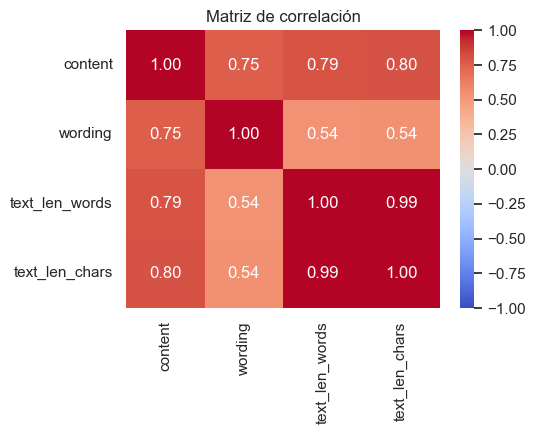

In [13]:
corr = summaries_train[["content", "wording", "text_len_words", "text_len_chars"]].corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

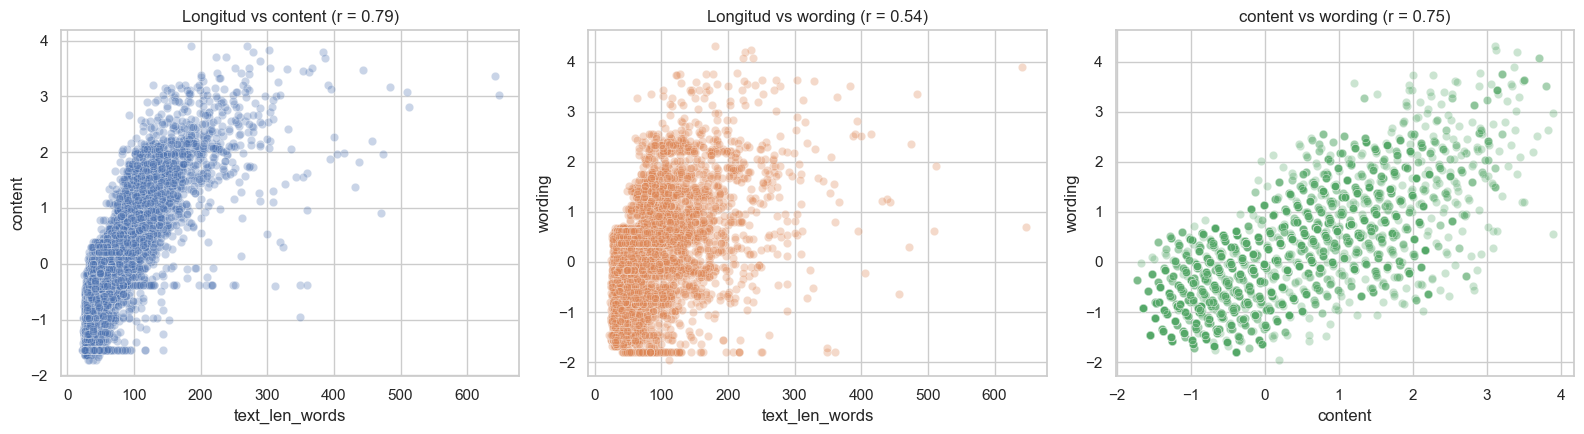

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.scatterplot(data=summaries_train, x="text_len_words", y="content", alpha=0.3, ax=axes[0])
axes[0].set_title(f"Longitud vs content (r = {corr.loc['text_len_words','content']:.2f})")

sns.scatterplot(data=summaries_train, x="text_len_words", y="wording", alpha=0.3, ax=axes[1], color="#DD8452")
axes[1].set_title(f"Longitud vs wording (r = {corr.loc['text_len_words','wording']:.2f})")

sns.scatterplot(data=summaries_train, x="content", y="wording", alpha=0.3, ax=axes[2], color="#55A868")
axes[2].set_title(f"content vs wording (r = {corr.loc['content','wording']:.2f})")

plt.tight_layout()
plt.show()

**Hallazgos:**

- La longitud del resumen (`text_len_words`) tiene una correlación fuerte y positiva con `content` (r ≈ 0.79) y moderada con `wording` (r ≈ 0.54). Esto es intuitivo: para representar bien el contenido de un texto fuente largo suele hacer falta un resumen más desarrollado, aunque la relación no es perfecta, ya que un resumen puede ser extenso y aun así de baja calidad (redundante o que se desvíe del tema).
- `content` y `wording` están fuertemente correlacionadas entre sí (r ≈ 0.75): un resumen que representa bien el contenido tiende también a estar mejor redactado. Sin embargo, la correlación no es perfecta, lo que confirma que son dos dimensiones relacionadas pero distintas de la calidad de un resumen, y que vale la pena modelarlas como dos variables objetivo separadas (tal como lo plantea la competencia).
- La dispersión de los puntos alrededor de la tendencia positiva longitud-`content` es notable para resúmenes muy cortos o muy largos, lo que indica que la longitud por sí sola no es un predictor suficiente y que se necesitan variables adicionales (por ejemplo, superposición léxica con el texto fuente) para explicar completamente la calidad del resumen.

## 6. Hallazgos y conclusiones

### 6.1 Resumen de hallazgos

- **Estructura y calidad de los datos:** `summaries_train.csv` contiene 7,165 resúmenes (5 variables) escritos sobre 4 textos fuente distintos, descritos en `prompts_train.csv`. El dataset llega limpio: no hay valores faltantes, no hay `student_id` duplicados y los `prompt_id` de ambas tablas coinciden exactamente, por lo que no fue necesario imputar ni descartar observaciones.
- **Variables objetivo (`content` y `wording`):** son puntuaciones continuas ya estandarizadas (media ≈ 0, desviación ≈ 1), con distribución aproximadamente normal pero con sesgo positivo (cola derecha más larga de resúmenes sobresalientes). Están fuertemente correlacionadas entre sí (r ≈ 0.75), pero no son intercambiables: miden dimensiones relacionadas aunque distintas de la calidad de un resumen (qué se dijo vs. cómo se dijo).
- **Longitud del resumen:** varía enormemente entre estudiantes (22 a 647 palabras) y es la variable individual más asociada con `content` (r ≈ 0.79) y, en menor medida, con `wording` (r ≈ 0.54). Sin embargo, la dispersión alrededor de esa tendencia muestra que la longitud por sí sola no basta para explicar la calidad del resumen.
- **Efecto del prompt:** las observaciones no están balanceadas entre los 4 prompts (entre 15% y 29% cada uno), y tanto la media de `content` como la de `wording` difieren según el texto fuente. Esto indica que la dificultad/naturaleza del texto original afecta el desempeño de los estudiantes, y que el modelo final deberá generalizar a textos fuente no vistos en entrenamiento (train y test no comparten prompts).
- **Valores atípicos:** el método IQR detecta ≈2.4% de outliers en `content` y ≈1.2% en `wording`, todos en la cola superior (resúmenes excepcionalmente buenos). Se decidió conservarlos por ser casos válidos y relevantes, no errores de datos.

### 6.2 Conclusiones y próximos pasos

El análisis exploratorio confirma que este es, ante todo, un problema de NLP con una fuerte componente de comparación texto-fuente vs. resumen, y no solo de evaluación de un texto aislado: la longitud y otras características superficiales del resumen explican una parte importante, pero no la totalidad, de la variabilidad en `content` y `wording`. Esto sugiere que un futuro modelo predictivo se beneficiará de incorporar características que midan explícitamente la relación entre el resumen y su texto fuente (por ejemplo, superposición de n-gramas, similitud de embeddings o medidas tipo ROUGE), además de características puramente del resumen (longitud, diversidad léxica, errores gramaticales).

El marcado desbalance y la baja cantidad de prompts (solo 4 en entrenamiento, ninguno compartido con el conjunto de prueba) es el principal reto identificado: cualquier estrategia de validación debe evitar que el modelo se sobreajuste a los 4 textos fuente vistos, por ejemplo mediante validación cruzada agrupada por `prompt_id` (*group k-fold*), en lugar de una partición aleatoria simple. Asimismo, dado que `content` y `wording` están correlacionadas pero no son iguales, se concluye que ambas deben modelarse (ya sea con modelos independientes o multi-salida), en lugar de asumir que predecir una es suficiente para inferir la otra.

En síntesis, los datos son de buena calidad y suficientes para avanzar hacia una etapa de ingeniería de características y modelado, priorizando: (1) características de similitud resumen-texto fuente, (2) características de longitud y complejidad lingüística del resumen, y (3) una estrategia de validación que respete la separación por `prompt_id` para medir honestamente la capacidad de generalización del modelo a textos fuente nuevos.